In [2]:
import numpy as np
import matplotlib.pyplot as plt

Total curves generated: 10000
Total filtered curves: 9937


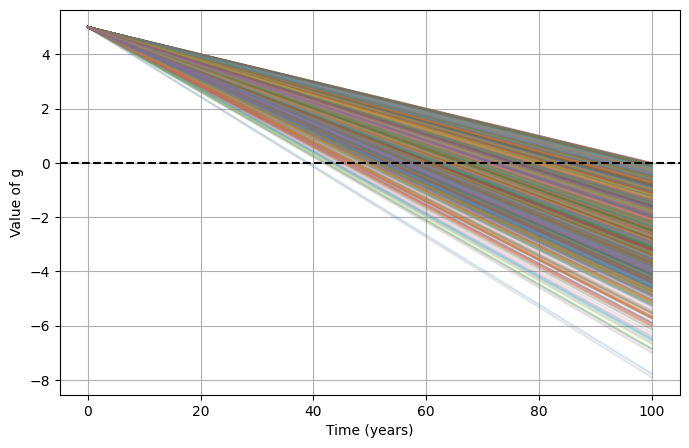

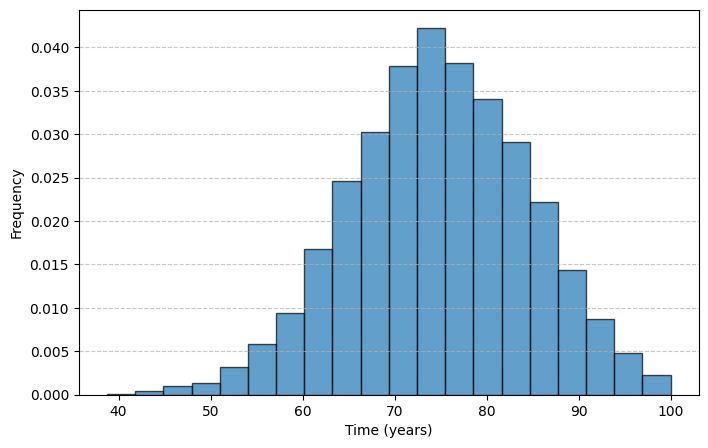

In [3]:
# Parameters
time = np.arange(0, 101, 1)  # years from 0 to 100
initial_value = 5.0
n_samples = 10000

# Dataset generation
dataset = []
for _ in range(n_samples):
    decay_time = np.random.normal(75, 10, 1)[0]
    g = initial_value * (1 - time / decay_time)
    dataset.append(g)

dataset = np.array(dataset)

# Filtering: only curves that cross g=0
filtered_curves = []
crossing_times = []

for g in dataset:
    if np.any(g <= 0):
        for i in range(1, len(g)):
            if g[i-1] > 0 and g[i] <= 0:
                # Interpolation for exact crossing time
                t1, t2 = time[i-1], time[i]
                g1, g2 = g[i-1], g[i]
                cross_time = t1 - g1 * (t2 - t1) / (g2 - g1)
                crossing_times.append(cross_time)
                filtered_curves.append(g)
                break

filtered_curves = np.array(filtered_curves)

# Save to use in another script
np.save("time.npy", time)
np.save("curves.npy", filtered_curves)

# Info prints
print(f"Total curves generated: {len(dataset)}")
print(f"Total filtered curves: {len(filtered_curves)}")

# Plot filtered curves
plt.figure(figsize=(8, 5))
for g in filtered_curves:
    plt.plot(time, g, alpha=0.2)
plt.axhline(0, color='k', linestyle='--')
plt.xlabel('Time (years)')
plt.ylabel('Value of g')
plt.grid()
plt.show()

# Histogram of crossing times (as probability density)
plt.figure(figsize=(8, 5))
plt.hist(crossing_times, bins=20, edgecolor='black', alpha=0.7, density=True)
plt.xlabel('Time (years)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



Total curves in dataset: 9937
Total curves crossing vertical line at year 35.0: 9937


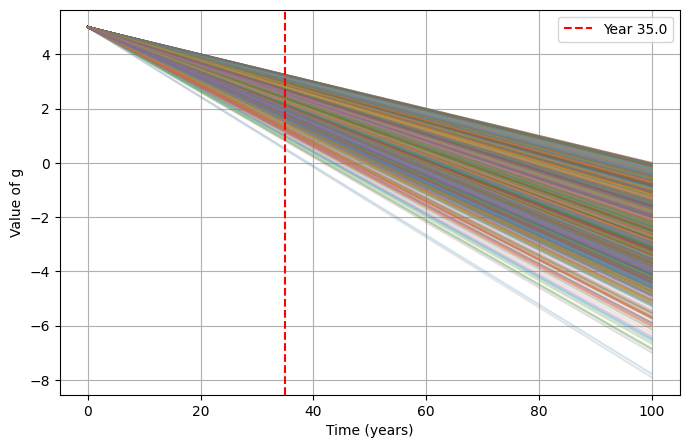

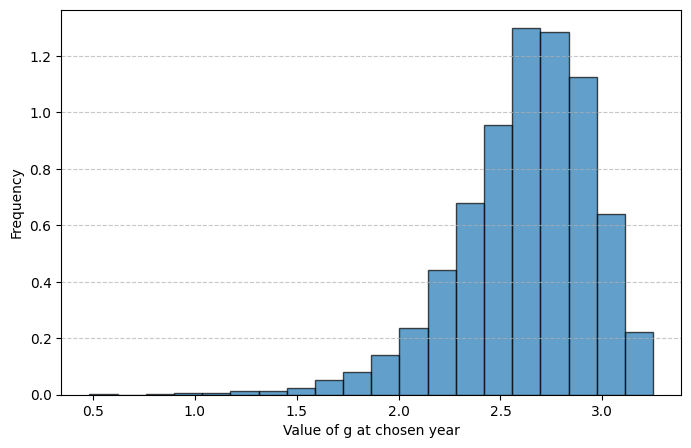

In [4]:
# Load saved data
time = np.load("time.npy")
curves = np.load("curves.npy")

# User input
chosen_year = float(input("Enter the year (0 to 100): "))
if chosen_year < 0 or chosen_year > 100:
    raise ValueError("The year must be between 0 and 100.")

# Save the chosen year for use in Code 3
np.save("chosen_year.npy", chosen_year)

# List to store g values at the chosen year
g_values_at_year = []

for g in curves:
    if chosen_year in time:
        g_val = g[int(chosen_year)]
    else:
        g_val = np.interp(chosen_year, time, g)
    g_values_at_year.append(g_val)

# Counts
total_curves = len(curves)
total_crossing = len(g_values_at_year)
print(f"Total curves in dataset: {total_curves}")
print(f"Total curves crossing vertical line at year {chosen_year}: {total_crossing}")

# Plot curves with vertical line
plt.figure(figsize=(8, 5))
for g in curves:
    plt.plot(time, g, alpha=0.2)
plt.axvline(x=chosen_year, color='r', linestyle='--', label=f"Year {chosen_year}")
plt.xlabel('Time (years)')
plt.ylabel('Value of g')
plt.legend()
plt.grid()
plt.show()

# Histogram of g values at intersection
plt.figure(figsize=(8, 5))
plt.hist(g_values_at_year, bins=20, edgecolor='black', alpha=0.7, density=True)
plt.xlabel('Value of g at chosen year')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


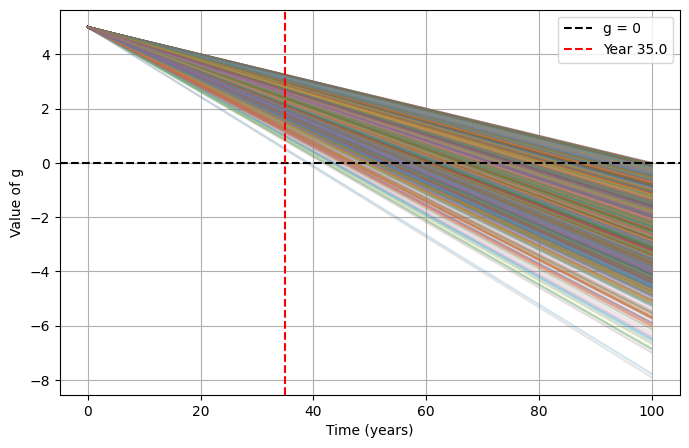

In [5]:
# Load saved data
time = np.load("time.npy")
curves = np.load("curves.npy")
chosen_year = np.load("chosen_year.npy")  # year defined in Code 2

# Combined plot
plt.figure(figsize=(8, 5))
for g in curves:
    plt.plot(time, g, alpha=0.2)

# Add the two lines
plt.axhline(0, color='k', linestyle='--', label="g = 0")
plt.axvline(x=chosen_year, color='r', linestyle='--', label=f"Year {chosen_year}")

# Graph configuration
plt.xlabel('Time (years)')
plt.ylabel('Value of g')
plt.legend()
plt.grid()
plt.show()


Total curves considered: 9937
Crossings after year 35.0: 9937


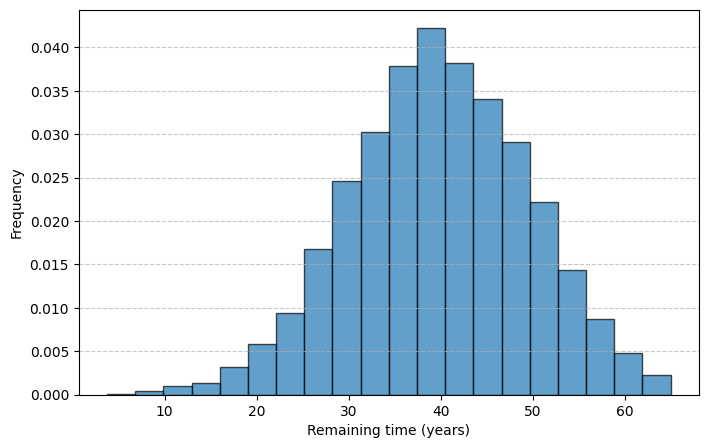

In [6]:
# Load data
time = np.load("time.npy")
curves = np.load("curves.npy")
chosen_year = np.load("chosen_year.npy")

remaining_times = []

for g in curves:
    # Check if curve crosses g=0
    if np.any(g <= 0):
        for i in range(1, len(g)):
            if g[i-1] > 0 and g[i] <= 0:
                # Interpolation for exact crossing time
                t1, t2 = time[i-1], time[i]
                g1, g2 = g[i-1], g[i]
                crossing_time = t1 - g1 * (t2 - t1) / (g2 - g1)
                
                # Only consider crossings after the chosen year
                if crossing_time > chosen_year:
                    remaining_times.append(crossing_time - chosen_year)
                break

# Basic statistics
print(f"Total curves considered: {len(curves)}")
print(f"Crossings after year {chosen_year}: {len(remaining_times)}")

# Histogram of remaining times
plt.figure(figsize=(8,5))
plt.hist(remaining_times, bins=20, edgecolor='black', alpha=0.7, density=True)
plt.xlabel(f"Remaining time (years)")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


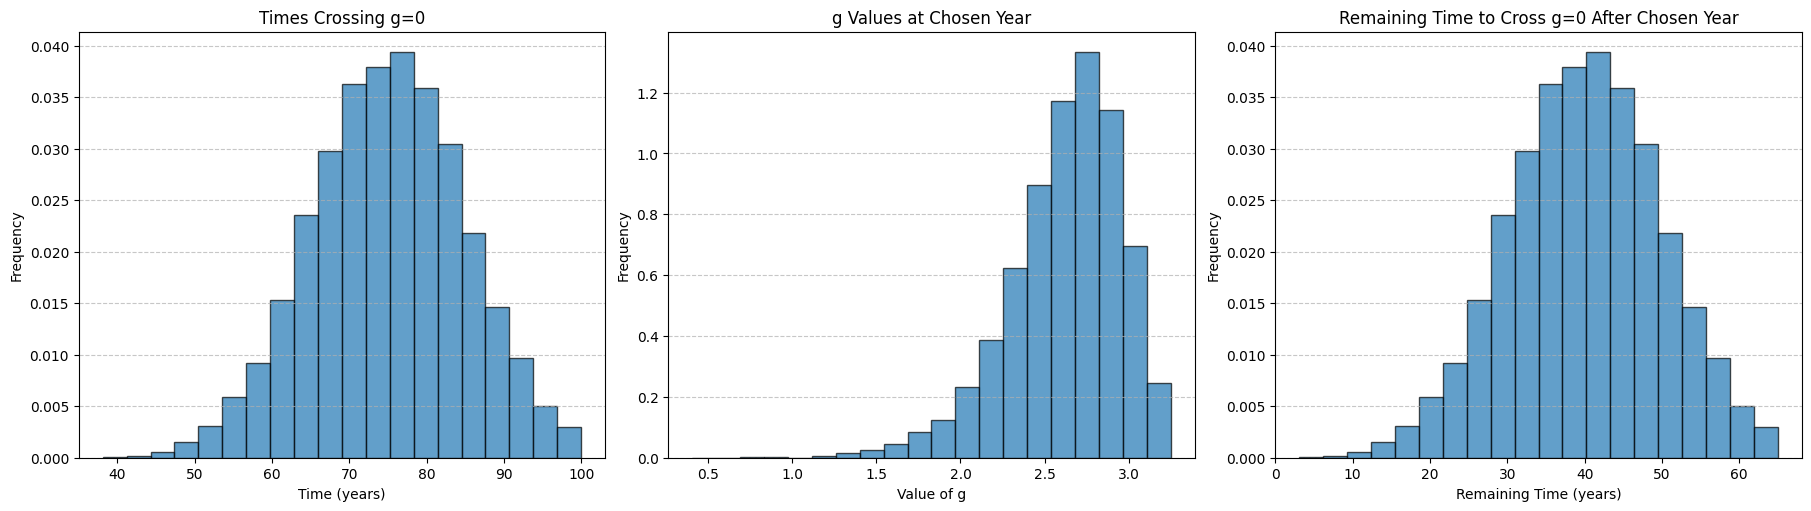

In [ ]:

fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

# Histogram 1: Times curves cross g=0 (original)
axs[0].hist(crossing_times, bins=20, edgecolor='black', alpha=0.7, density=True)
axs[0].set_title('Times Crossing g=0')
axs[0].set_xlabel('Time (years)')
axs[0].set_ylabel('Frequency')
axs[0].grid(axis='y', linestyle='--', alpha=0.7)

# Histogram 2: g values at the chosen year
axs[1].hist(g_values_at_year, bins=20, edgecolor='black', alpha=0.7, density=True)
axs[1].set_title('g Values at Chosen Year')
axs[1].set_xlabel('Value of g')
axs[1].set_ylabel('Frequency')
axs[1].grid(axis='y', linestyle='--', alpha=0.7)

# Histogram 3: Remaining time after chosen year until crossing g=0
axs[2].hist(remaining_times, bins=20, edgecolor='black', alpha=0.7, density=True)
axs[2].set_title('Remaining Time to Cross g=0 After Chosen Year')
axs[2].set_xlabel('Remaining Time (years)')
axs[2].set_ylabel('Frequency')
axs[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.show()



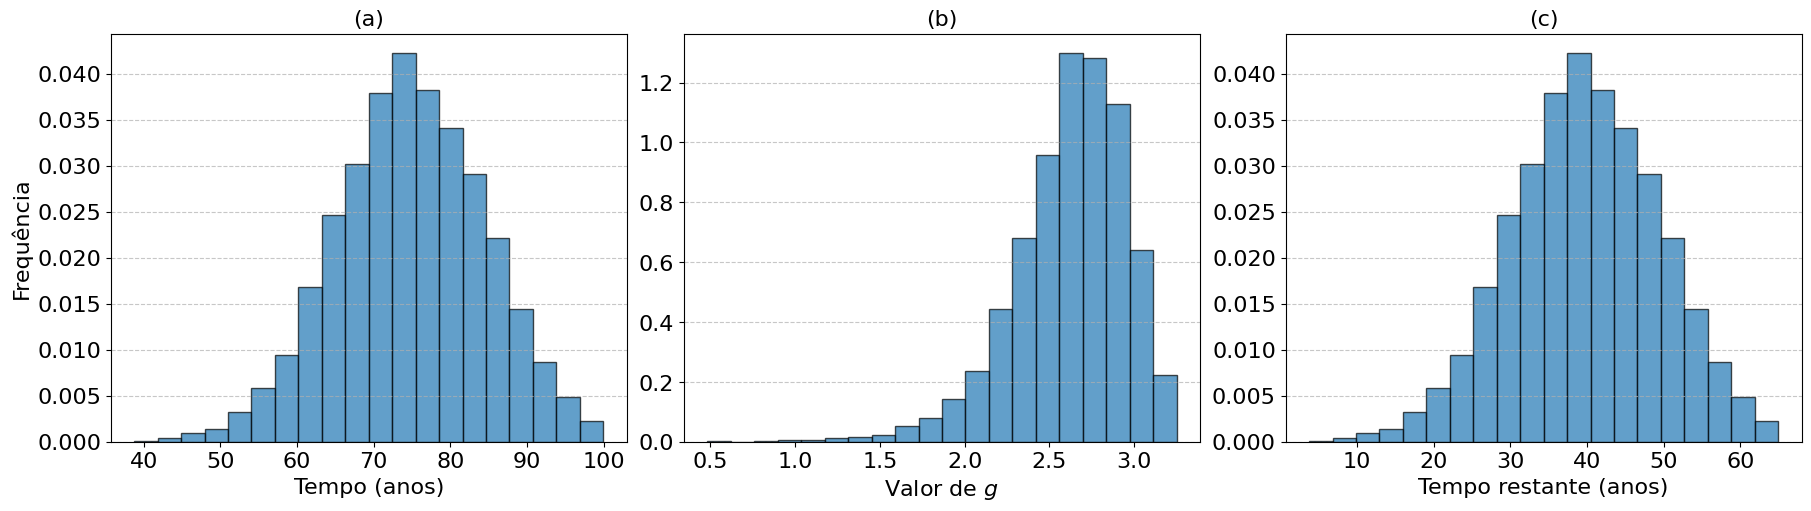

In [19]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

# Ajuste do tamanho das fontes
label_size = 16   # tamanho dos rótulos dos eixos
title_size = 16  # tamanho dos títulos
tick_size = 16   # tamanho dos números nos eixos

# Histograma (a)
axs[0].hist(crossing_times, bins=20, edgecolor='black', alpha=0.7, density=True)
axs[0].set_title('(a)', fontsize=title_size)
axs[0].set_xlabel('Tempo (anos)', fontsize=label_size)
axs[0].set_ylabel('Frequência', fontsize=label_size)
axs[0].tick_params(axis='both', labelsize=tick_size)
axs[0].grid(axis='y', linestyle='--', alpha=0.7)

# Histograma (b)
axs[1].hist(g_values_at_year, bins=20, edgecolor='black', alpha=0.7, density=True)
axs[1].set_title('(b)', fontsize=title_size)
axs[1].set_xlabel('Valor de $g$', fontsize=label_size)

axs[1].tick_params(axis='both', labelsize=tick_size)
axs[1].grid(axis='y', linestyle='--', alpha=0.7)

# Histograma (c)
axs[2].hist(remaining_times, bins=20, edgecolor='black', alpha=0.7, density=True)
axs[2].set_title('(c)', fontsize=title_size)
axs[2].set_xlabel('Tempo restante (anos)', fontsize=label_size)

axs[2].tick_params(axis='both', labelsize=tick_size)
axs[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.show()



Tempo limite (espelhado) = 67.81 anos


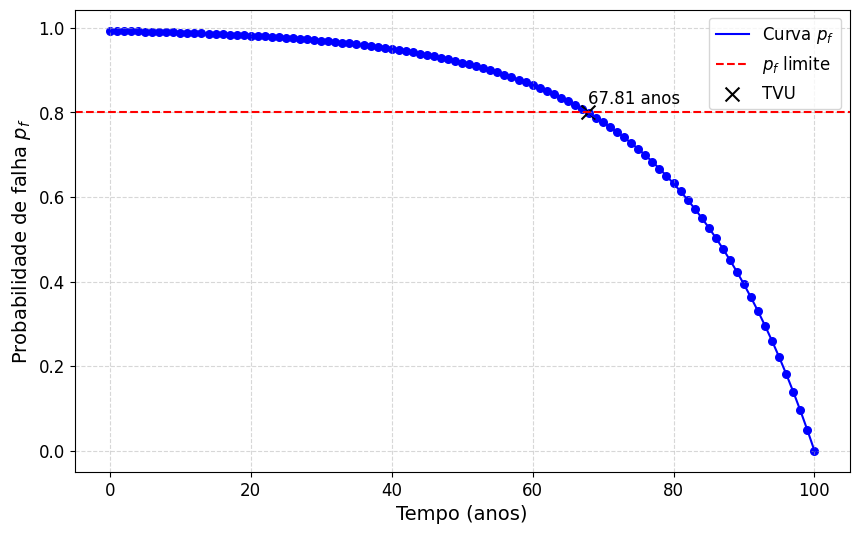

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.optimize import bisect

def verifica_tempo_limite_espelhado_x(pf_list: np.ndarray, temp_list: np.ndarray, pf_limit: float, plotar: bool = True) -> float:
    """
    Determina o tempo em que a probabilidade de falha da estrutura atinge o valor limite (pf_limit),
    espelhando a curva em relação ao eixo X.
    """

    # Ordena os dados pelo tempo
    sorted_indices = np.argsort(temp_list)
    X1 = np.array(temp_list)[sorted_indices]
    Y1 = np.array(pf_list)[sorted_indices]

    # Espelhamento horizontal
    X1_espelhado = X1[-1] - X1

    # Reordena para spline: deve ser estritamente crescente
    reorder_indices = np.argsort(X1_espelhado)
    X1_espelhado_sorted = X1_espelhado[reorder_indices]
    Y1_sorted = Y1[reorder_indices]

    # Função spline
    f1 = CubicSpline(X1_espelhado_sorted, Y1_sorted)

    # Função diferença para encontrar interseção
    def diff(x):
        return f1(x) - pf_limit

    # Busca do ponto de interseção
    x_values = np.linspace(X1_espelhado_sorted[0], X1_espelhado_sorted[-1], 1000)
    x_cross, y_cross = None, None
    for i in range(len(x_values)-1):
        if diff(x_values[i]) * diff(x_values[i+1]) < 0:
            x_cross = bisect(diff, x_values[i], x_values[i+1])
            y_cross = f1(x_cross)
            # Converte o valor espelhado de volta para o tempo original
            x_cross_original = X1[-1] - x_cross
            tempo_espelhado = 100 - x_cross_original
            print(f"Tempo limite (espelhado) = {tempo_espelhado:.2f} anos")

            break

    # Plotagem do gráfico
    if plotar:
        plt.figure(figsize=(10, 6))
        plt.plot(X1_espelhado_sorted, Y1_sorted, color='blue', label="Curva $p_f$")
        plt.scatter(X1_espelhado_sorted, Y1_sorted, color='blue', marker='o', s=30)
        plt.axhline(y=pf_limit, color='red', linestyle='--', label="$p_f$ limite")
        if x_cross is not None and y_cross is not None:
            plt.scatter(x_cross, y_cross, color='black', marker='x', s=100, label="TVU")
            plt.text(x_cross, y_cross + 0.02, f"{tempo_espelhado:.2f} anos", fontsize=12, ha='left')

        plt.xlabel("Tempo (anos)", fontsize=14)
        plt.ylabel("Probabilidade de falha $p_f$", fontsize=14)
  
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend(fontsize=12, loc='upper right')
        plt.xticks(fontsize=12)
        plt.yticks(fontsize=12)
        plt.show()

    return x_cross_original if x_cross is not None else None


# Exemplo de uso
temp_list = np.linspace(0, 100, 101)
pf_list = 1 - np.exp(-0.05 * temp_list)
pf_limit = 0.8

temp_limit = verifica_tempo_limite_espelhado_x(pf_list, temp_list, pf_limit)
